# Titanic Exploratory Data Analysis

This project explores the titanic dataset to analyze one's survival probabaility based of factors like:
- Passenger class
- Age
- Sex

My goal is to answer questions relevant to the analysis of our data:
- Which passengers survived?
- How did their place in the ship affect their survivals?
  
 **Outline**
 - Import Libraries
 - load dataset
 - Explore dataset
 - clean dataset
 - visualizations
 - Key Insights

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('complete')

complete


# 2. Load dataset

In [4]:
titanic_dataset=(r"C:\Users\Admin\Desktop\Data Science projects\Titanic.csv")
titanic=pd.read_csv(titanic_dataset)
titanic.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 3. Explore Dataset

In [6]:
titanic.shape

(891, 16)

The dataset has 16 columns and 891 row

Each row represent an individual passenger 

In [7]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    str    
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    str    
 9   class        891 non-null    str    
 10  who          891 non-null    str    
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    str    
 13  embark_town  889 non-null    str    
 14  alive        891 non-null    str    
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), str(7)
memory usage: 99.3 KB


data tyoes are: bool(2), float64(2), int64(5), str(7)

Some of the columns have mismatched data types(ie; survived column is an integer instead of a boolean)

The dataset also has missing values


In [8]:
titanic.describe()

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


This are the the basic summary statistics for our numerical columns

The avaerage passenger was about 26 years old and they paid around 32 dollars for the fare

In [10]:
titanic.describe(include='object')

C:\Users\Admin\AppData\Local\Temp\ipykernel_16132\26763510.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic.describe(include='object')


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


This gives the summary for the categorical variables

The average passenger was a man aboard third class and they did not survive

The were only 2 sexes aboard all who embarked on either one for three stations and placed in one of seven decks

In [12]:
titanic.isnull().sum()

Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

There are 177 age entries,688 deck entries,2 embarked and 2 embark_town missing entries

In [14]:
titanic.duplicated().sum()

np.int64(0)

There are no duplicated entries in our dataset

# 3. Clean dataset

In [151]:
titanic['survived']=titanic['survived'].astype(bool)
titanic['alive']=titanic['alive'].astype(bool)

titanic['alone'] = np.where(titanic['alone'] == True, 'Yes', 'No')
titanic.dtypes

Unnamed: 0       int64
survived          bool
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive             bool
alone              str
dtype: object

In [124]:
titanic.head()
titanic['survived']==False

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: survived, Length: 891, dtype: bool

I fixed the mismatched data types from the survived and alive column and dictated the boolean values to yes or no for both columns as well as the alone column

In [116]:
titanic['deck']=titanic['deck'].fillna('Unknown')
titanic['age']=titanic['age'].fillna(titanic['age'].mode()[0])
titanic['embark_town']=titanic['embark_town'].fillna('Unknown')
titanic['embarked']=titanic['embarked'].fillna('Unknown')
titanic


,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,True,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,True,No
1,1,True,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,True,No
2,2,True,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,True,No
3,3,True,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,True,No
4,4,True,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,True,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,True,2,male,27.0,0,0,13.0000,S,Second,man,True,Unknown,Southampton,True,No
887,887,True,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True,No
888,888,True,3,female,24.0,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,True,No
889,889,True,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,True,No


I have filled in the missing entries:
- age with the mode age
- deck,emabark town and embarked  with unknown
  

The data is now set for aggregating and visualizations

# 4. Visualizations

In [95]:
sns.set_style('darkgrid')

# 4.1 Univariate Analysis

The goal of this section is to determine how the passengers were distributed; by gender,class aboard,by survival rate etc.

In [92]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

Text(0.5, 1.0, 'Survival by Gender')

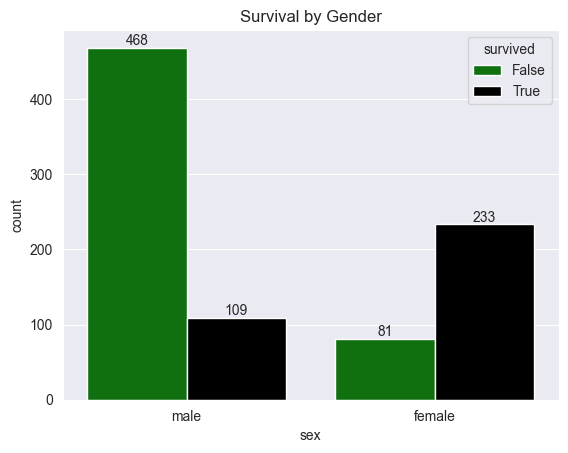

In [154]:
ax=sns.countplot(data=titanic ,x='sex',hue='survived',palette=['Green','black'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Survival by Gender')

**Observation:**
- The bar chart compares survival outcomes across gender. Among male passengers, 468 did not survive and only 109 who did. Female passengers show the opposite pattern, with 233 surviving compared to just 81 who did not.
  
**Explanation:**
- Gender is one of the strongest predictors of survival in this dataset.
- The "women and children first" evacuation protocol on the Titanic is  reflected here — female passengers were  more likely to survive than male passengers.
-  Males account for the  majority of fatalities, while females account for the majority of survivors.

**Insight:**

This data highlights:
- The strong influence of evacuation protocols on survival outcomes by gender.That being male was one of the highest risk factors for not surviving
- Gender should be treated as a high-importance feature in any predictive survival model built on this dataset

In [144]:
titanic.groupby(['pclass','sex']).size()

pclass  sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

Text(0.5, 1.0, 'Survival by Passenger class')

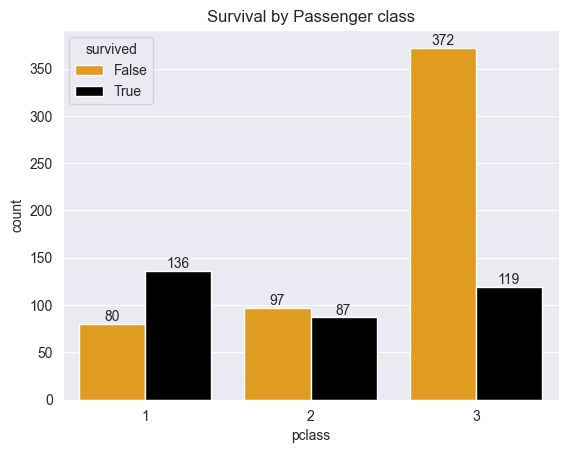

In [161]:
ax=sns.countplot(data=titanic,x='pclass',hue='survived',palette=['orange','black'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Survival by Passenger class')

**Observation:**

The chart shows survival counts across three passenger classes. First class has more survivors (136) than non-survivors (80), making it the only class where survivors outnumber fatalities. Second class shows a near-even split — 97 did not survive versus 87 who did. Third class tells a different story, with 372 fatalities and only 119 survivors.

**Explanation:**
- Passenger class is a strong indicator of survival, likely because first-class cabins were located on higher decks closer to lifeboats, and first-class passengers may have had preferential access to evacuation resources.
-  Third-class passengers, housed in lower decks, faced the greatest barriers to reaching lifeboats in time.
**Insight:**

This data reveals:
- Socioeconomic status played a significant role in determining survival chances
- Cabin location by class compounded the disadvantage faced by lower-class passengers
- Passenger class should be included as a key feature in any survival prediction model

Text(0.5, 1.0, 'Age distribution')

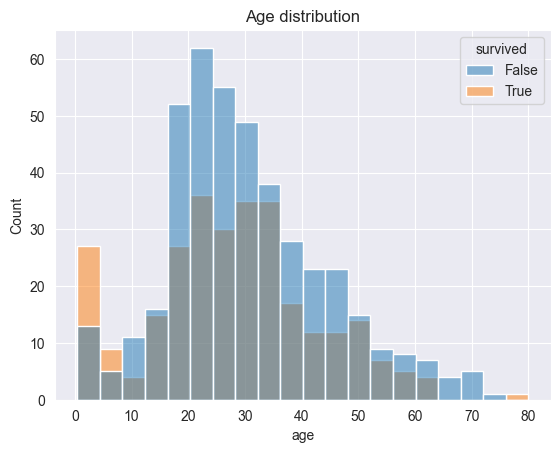

In [162]:
sns.histplot(data=titanic,x='age',hue='survived')
plt.title('Age distribution')

**Observation:**

The histogram shows the age distribution of passengers split by survival status.

The overall distribution is right-skewed, peaking around ages 20–30. Non-survivors (blue) dominate across nearly all age ranges. A notable orange (survived) spike appears in the 0–5 age range, suggesting young children had comparatively higher survival rates.

Non-survival counts are heaviest in the 20–40 age range.

**Explanation:**
- Young children appear to have benefited from prioritised evacuation, consistent with the "women and children first" protocol.
- The 20–40 age group, which likely includes many male passengers , shows the highest concentration of fatalities.
- Survival rates appear to taper off across older age groups, with very few passengers above 60 surviving.

**Insight:**
  
This data suggests:

- Age, particularly being a young child, was a meaningful survival advantage
- Young to middle-aged adults bore the highest proportion of casualties
- Age should be retained as a feature in predictive modelling, particularly the young child segment which shows a distinct survival pattern



In [163]:
titanic.groupby('deck')['survived'].size()

deck
A    15
B    47
C    59
D    33
E    32
F    13
G     4
Name: survived, dtype: int64

Text(0.5, 1.0, 'Survival by deck')

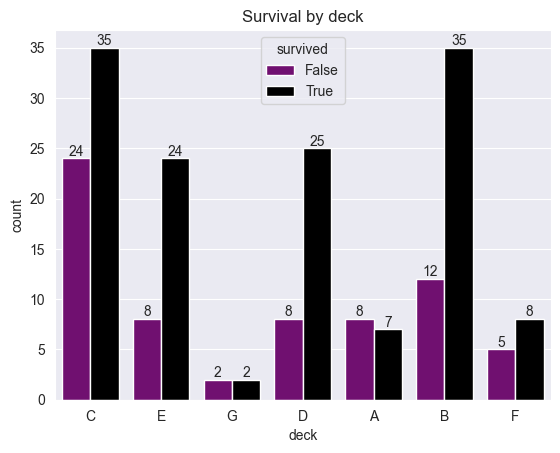

In [166]:
ax=sns.countplot(data=titanic,x='deck',hue='survived',palette=['purple','black'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Survival by deck')

**Observation:**

The chart shows survival outcomes across ship decks (A through G). Decks C and B stand out — Deck C has 35 survivors against 24 non-survivors, and Deck B also has 35 survivors against 12 non-survivors, both showing survival majorities. Deck E has an equal count of 24 non-survivors and 24 survivors. Deck D shows 25 survivors versus only 8 non-survivors — the strongest survival ratio. Decks A and G show relatively small and mixed counts.

**Explanation:**
- Passengers on higher decks (B, C, D) had significantly better survival outcomes, likely because these decks were physically closer to the lifeboats and upper deck evacuation points.
- Lower or less accessible decks such as G show near-equal or poor survival odds.
- This reinforces that physical location on the ship was a critical factor in survival.

**Insight:**

This data highlights:
- Deck assignment was meaningful  for evacuation accessibility and survival likelihood
- Decks B, C, and D should be flagged as high-survival zones when making a model

# Bivariate analysis

The goal of this section is to investigate the correlation between factors and how they affected a passenger's survival rate

**Corrlelation Map**

Text(0.5, 1.0, 'Correlation map for the numerical variables')

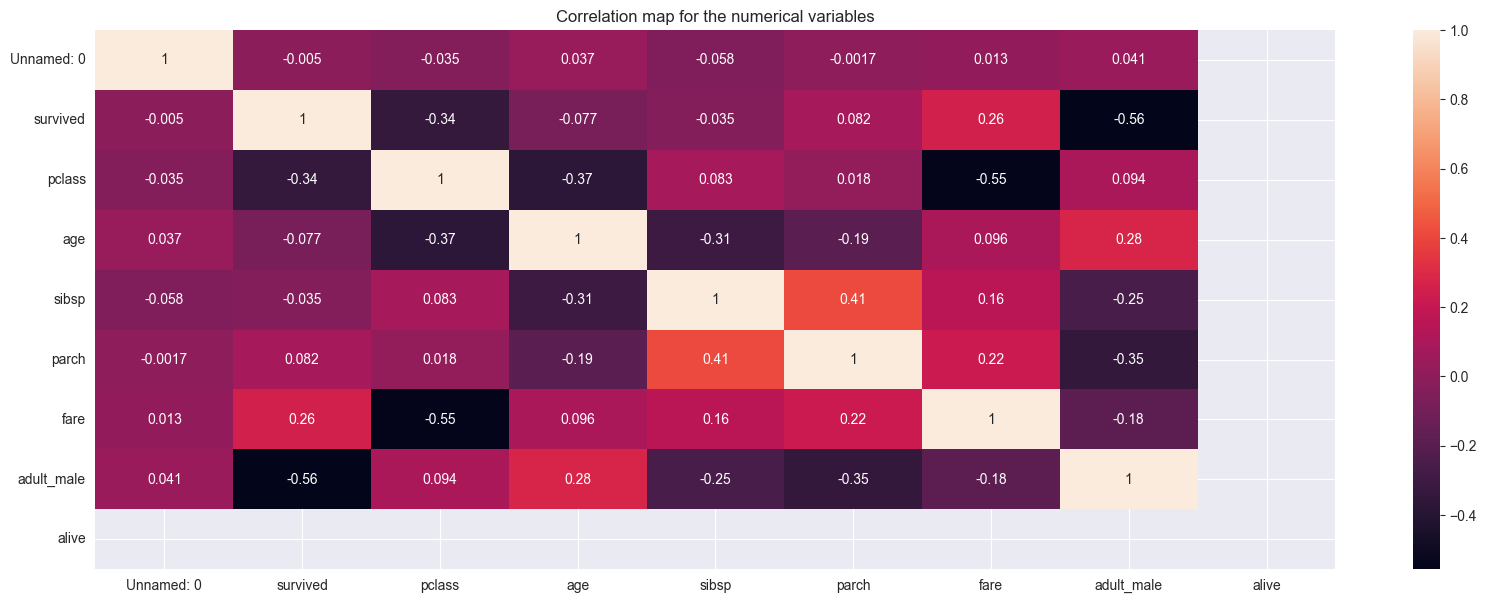

In [178]:
plt.figure(figsize=(20,7))
sns.heatmap(titanic.corr(numeric_only=True),annot=True)
plt.title('Correlation map for the numerical variables')

**Observation:**

The heatmap displays pairwise correlations between numerical variables. 

The strongest notable correlations include:
- adult_male and survived at -0.56,
- pclass and fare at -0.55
- pclass and survived at -0.34
- fare and survived at 0.26.

**Explanation:**
- The strong negative correlation between adult_male and survived confirms that being an adult male was the  biggest numerical predictor of not surviving.
- The negative correlation between pclass and fare makes logical sense — higher classes  paid more.
- The positive correlation between fare and survived further reinforces the class-based survival advantage.

**Insight:**

This data suggests:
- adult_male and fare are the most numerically significant predictors of survival and should be prioritised in feature selection for modelling
- pclass and fare are strongly linked and may introduce multicollinearity — one may need to be dropped or handled carefully in a modelling

# **Boxplots**

In [180]:
titanic['survived'].value_counts()

survived
False    549
True     342
Name: count, dtype: int64

<Axes: xlabel='pclass', ylabel='survived'>

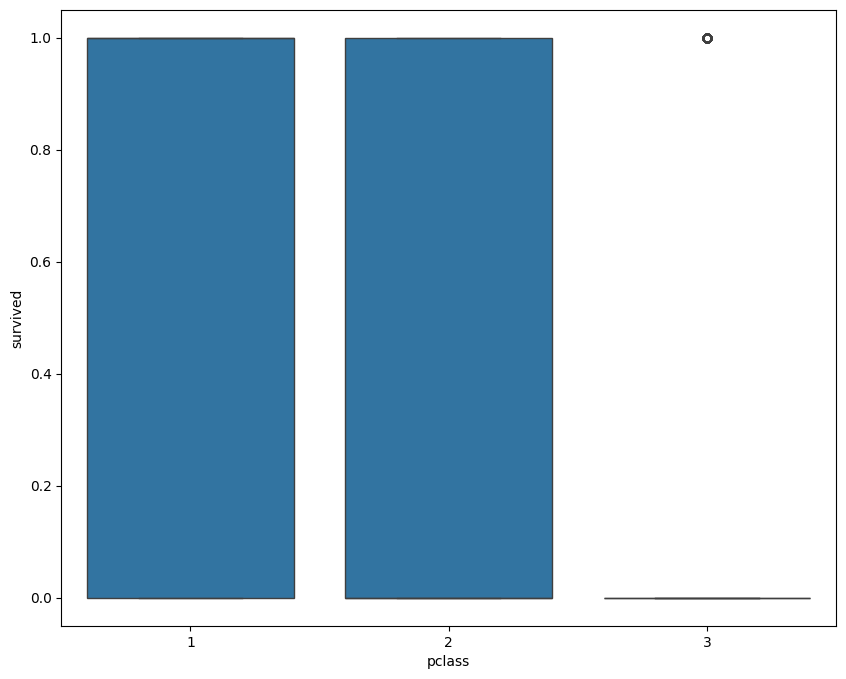

In [10]:
plt.figure(figsize=(10,8))
sns.boxplot(x='pclass',y='survived',data=titanic)

**Observation:**
- The box plot displays the distribution of survival outcomes across the three passenger classes. 
- First class  and second class both show a median survival value of 1.0, meaning the majority of passengers in these classes survived. 
- Third class shows a median survival value of approximately 0.0, indicating that most  passengers did not survive. 
- There is a single outlier point above the median for third class 
- The interquartile range is extremely compressed across all three classes, suggesting very little variability within each group.

**Explanation:**
- This plot shows first and second class cluster at survival (1.0) and third class clusters at non-survival (0.0) thereby reinforcing how decisive passenger class was in determining survival outcomes

**Insight:**

This data suggests:

- Passenger class acted as a near-decisive dividing line — upper classes survived, lower classes largely did not
- In a predictive model, pclass should be treated as one of the most powerful categorical features, particularly its ability to separate third-class passengers from the rest


# key Insights

**1. Gender was a key factor in survival**
- Female passengers largley survived while the male passengers did not.
- This is consistent with the women and children first evacuation protocol

**2. Socioeconomic status played a significant role in determining survival chances**
- Majority of the passengers who could afford first class survived while those in lower classes did not
- Females in first class had the highest chance of survival

**3. One's age had meaningful survival advantage**
- Children aged between 0-5 survived while passengers in the 20-40 range did not
- This is again consistent with women and children first evacuation protocol

**4. Deck assignment was meaningful for evacuation accessibility**
- Passengers on higher decks were able to access life boats easily
- Higher decks were likely preserved for higher passenger classes
- This checks out- Pclass 1 had the highest survvial chance